# Exercise 1

In [3]:
def generate_stripe_image(size, stripe_nr, vertical = True):
  img=np.zeros((size,size,1),dtype="uint8")
  for i in range(0,stripe_nr):
    x,y = np.random.randint(0,size,2)
    l  = np.random.randint(y,size,1).item()
    if (vertical):
      img[y:l,x,0]=255
    else:
      img[x,y:l,0]=255
  return img  

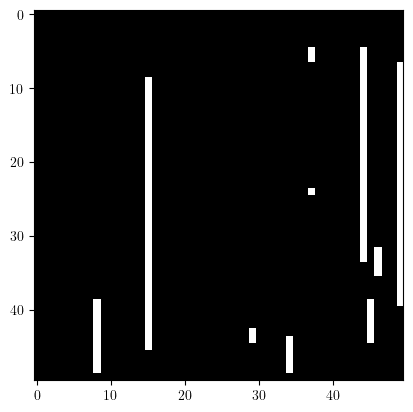

In [4]:
import matplotlib.pyplot as plt
import numpy as np

img=generate_stripe_image(50,10, vertical=True)
plt.imshow(img[:,:,0],cmap='gray')


In [ ]:
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

In [ ]:
conv_filter=model.get_weights()[0]

# Exercise 2

In [ ]:
csvname = datapath + 'multiple_sine_waves.csv'
data = np.loadtxt(csvname,delimiter=',')
x = data[:2,:]
y = data[2:,:]

In [ ]:
import autograd.numpy as np

def feature_transforms(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return np.sin(a).T

def model(x,w):    
    # feature transformation 
    f = feature_transforms(x,w[0])
    
    # compute linear combination and return
    a = w[1][0] + np.dot(f.T,w[1][1:])
    return a.T

# Exercise 3

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

alpha = 1.
model = keras.Sequential([
  layers.Dense(512, activation='relu'),
  layers.Dense(10, activation='softmax')
])
model.compile(optimizer=keras.optimizers.RMSprop(alpha),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history=model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

In [ ]:
model = keras.Sequential([layers.Dense(10, activation='softmax')])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

In [ ]:
model = keras.Sequential([
  layers.Dense(96, activation='relu'),
  layers.Dense(96, activation='relu'),
  layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

# Exercise 4

In [ ]:
# Import the necessary modules and libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
y_1 = regr_1.predict(X)
y_2 = regr_2.predict(X)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X, y_1, color="cornflowerblue",
         label="maxdepth=2", linewidth=2)
plt.plot(X, y_2, color="yellowgreen", label="maxdepth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [ ]:
def My_TreeRegressor(y,il,ir,max_depth,level=0):
    global yreg
    if (level==0): yreg=np.zeros(len(y))